In [1]:
from huggingface_hub import notebook_login
notebook_login()

In [2]:
import matplotlib.pyplot as plt
from datasets import load_dataset

ds = load_dataset(
    "mau-cr/mms_yua_results",
    data_files="scaling_results.csv",
    split="train",
)
df = ds.to_pandas()

In [3]:
ds.to_pandas()

,audio_minutes,wer_greedy,cer_greedy,wer_lm,cer_lm
0,20,0.533764,0.178228,0.242649,0.111447
1,40,0.493053,0.164059,0.239418,0.106456
2,60,0.480775,0.160177,0.221002,0.099556
3,80,0.465913,0.155372,0.210339,0.095983
4,100,0.451373,0.148411,0.217771,0.096907
5,120,0.427787,0.141511,0.198708,0.089207
6,140,0.421971,0.138553,0.194184,0.089268
7,160,0.431664,0.139108,0.196769,0.087790
8,180,0.405493,0.133132,0.174798,0.077748
9,200,0.404523,0.131838,0.174475,0.080520


<Figure size 1000x1000 with 0 Axes>

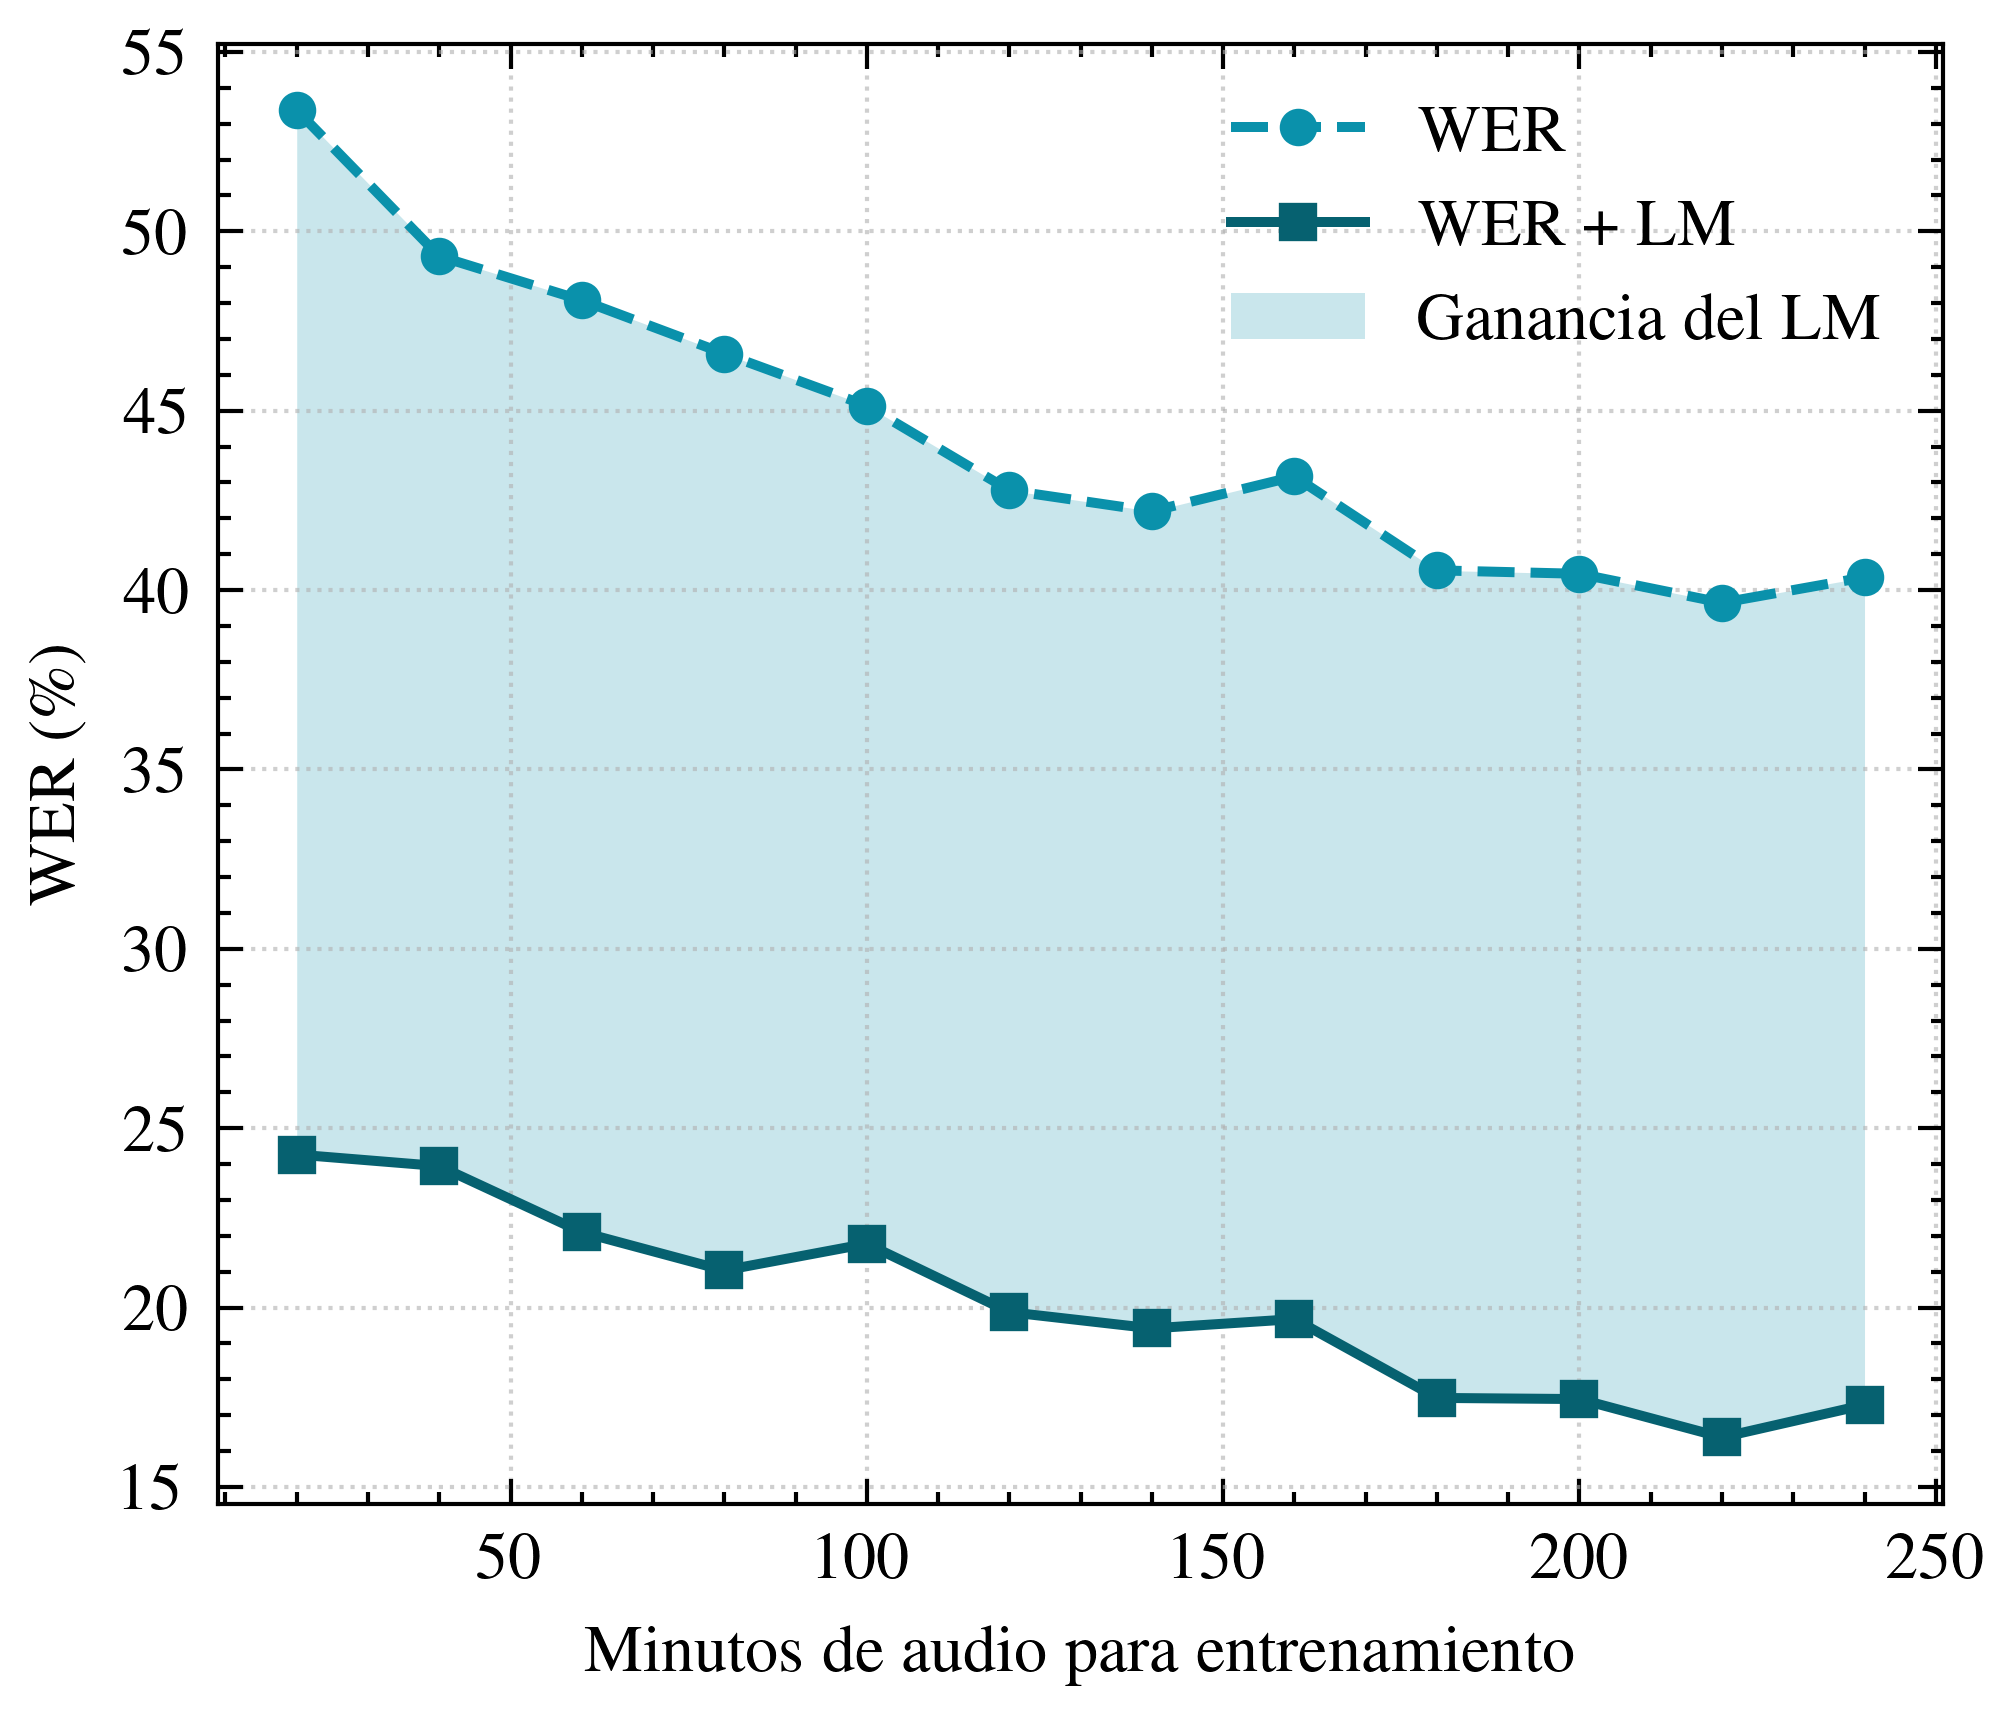

In [5]:
import matplotlib.pyplot as plt
import scienceplots

# 2. Ordenar por minutos de audio (clave para que las líneas y el área se vean limpias)
df = df.sort_values("audio_minutes").reset_index(drop=True)

x  = df["audio_minutes"].to_numpy()
y1 = df["wer_greedy"].to_numpy() * 100
y2 = df["wer_lm"].to_numpy() * 100

# 3. Paleta
BLUE       = "#0A91AB"   # el azul que pediste
BLUE_DEEP  = "#066170"   # versión más oscura del mismo tono, para WER + LM
BLUE_SOFT  = "#0A91AB"   # mismo azul pero con alpha bajo, para el sombreado

# 4. Gráfica con estilo science + ieee
fig = plt.figure(figsize=(10, 10))
with plt.style.context(["science", "ieee"]):

    fig, ax = plt.subplots(figsize=(3.5, 3.0))  # tamaños IEEE-friendly

    ax.plot(x, y1,
            linestyle="--", linewidth=1.2,
            color=BLUE, marker="o", markersize=3.5,
            label="WER")

    ax.plot(x, y2,
            linestyle="-", linewidth=1.2,
            color=BLUE_DEEP, marker="s", markersize=3.5,
            label="WER + LM")

    # Área sombreada entre las dos curvas
    ax.fill_between(x, y1, y2,
                    color=BLUE_SOFT, alpha=0.22,
                    linewidth=0,
                    label="Ganancia del LM")

    ax.set_xlabel("Minutos de audio para entrenamiento")
    ax.set_ylabel("WER (\\%)")          # escapa el % porque science usa LaTeX
    ax.legend(loc="best", frameon=False)
    ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6)

    plt.tight_layout()
    plt.savefig("wer_vs_audio_minutes.svg", dpi=300, bbox_inches="tight")
    plt.show()